# Criterio di selezione per i picchi

In [1]:
from lib.readwav import readwav
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import ipywidgets as widgets
import os

In [2]:
%matplotlib widget
plt.close('all')

In [110]:
available_files = [f for f in os.listdir('Data_organ') if f.endswith('.wav')]

available_files = sorted(available_files, key=lambda x: int(x.split("_")[1].split(".")[0]), reverse=False)

file_selector = widgets.Dropdown(
    options=available_files,
    description='Select file:',
)

display(file_selector)

Dropdown(description='Select file:', options=('note_1.wav', 'note_2.wav', 'note_3.wav', 'note_4.wav', 'note_5.…

In [111]:
num_periods_slider = widgets.IntSlider(value=5, min=1, max=200, step=1, description='Num Periods:')
display(num_periods_slider)

IntSlider(value=5, description='Num Periods:', max=200, min=1)

In [188]:
data = readwav(os.path.join('Data_organ', file_selector.value))

rate, data = data
channel1 = data[:,0]
channel2 = data[:,1]

In [189]:
n = np.arange(channel1.size)
N = len(channel1)


signal_peaks, _ = sp.signal.find_peaks(channel1[N//2-5000:N//2+5000], height=np.max(channel1)*0.1)
differences = np.diff(signal_peaks)
period = np.mean(differences) / rate

n_periods_in_window = num_periods_slider.value
window_size = int(n_periods_in_window * period * rate)
gaussian_window = np.exp(-0.5 * ((n - N/2) / (window_size/2))**2)


def apply_gaussian_window(signal, window_size, center):
    n = np.arange(len(signal))
    gaussian_window = np.exp(-0.5 * ((n - center) / (window_size/2))**2)
    return signal * gaussian_window


Estimated period: 0.0037 seconds
Number of peaks in filtered signal: 65


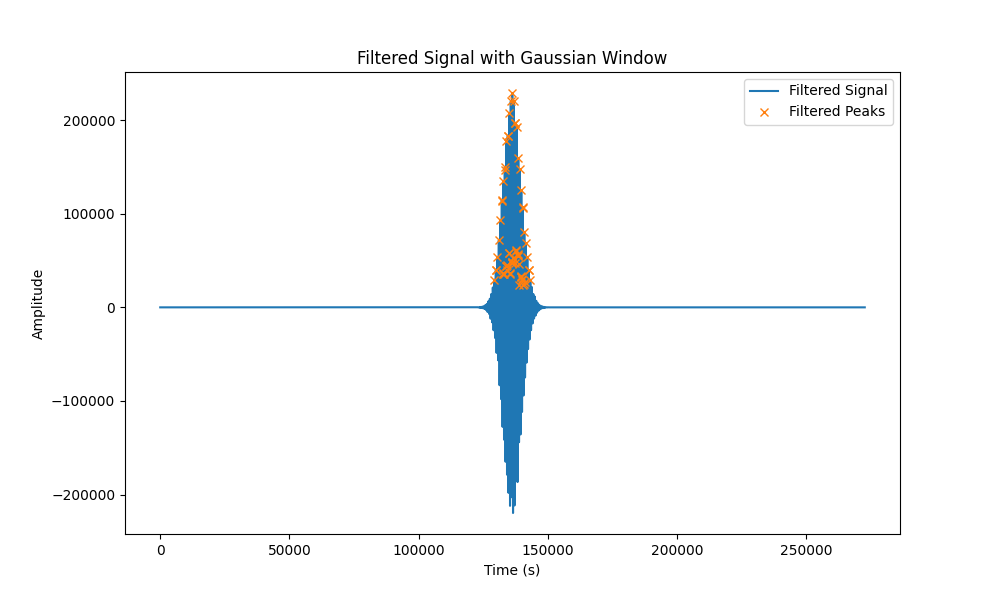

In [190]:
filtered_signal = np.multiply(np.asarray(channel1, dtype=float), gaussian_window)

filtered_peaks, _ = sp.signal.find_peaks(filtered_signal, height=np.max(filtered_signal)*0.1)

print(f"Estimated period: {period:.4f} seconds")
print(f"Number of peaks in filtered signal: {len(filtered_peaks)}")

plt.figure(figsize=(10, 6))
plt.plot(filtered_signal, label='Filtered Signal')
plt.plot(filtered_peaks, filtered_signal[filtered_peaks], "x", label='Filtered Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Filtered Signal with Gaussian Window')
plt.legend()
plt.show()

In [191]:
n_steps = len(range(1, channel1.shape[0], 1000))
freqs_channel1 = sp.fft.rfftfreq(len(channel1), 1/rate)
average_spectrum = np.zeros(len(freqs_channel1))

for i in range(1, channel1.shape[0], 1000):
    filtered_signal = apply_gaussian_window(channel1, window_size, i)
    fft_channel1 = sp.fft.rfft(filtered_signal)
    average_spectrum += np.abs(fft_channel1)**2

average_spectrum /= n_steps


In [192]:
log_freqs = np.log10(freqs_channel1[1:])  # Escludi la frequenza zero
log_spectrum = np.log10(average_spectrum[1:])  # Escludi la frequenza zero

peaks, _ = sp.signal.find_peaks(log_spectrum, prominence=0.9, distance=100)

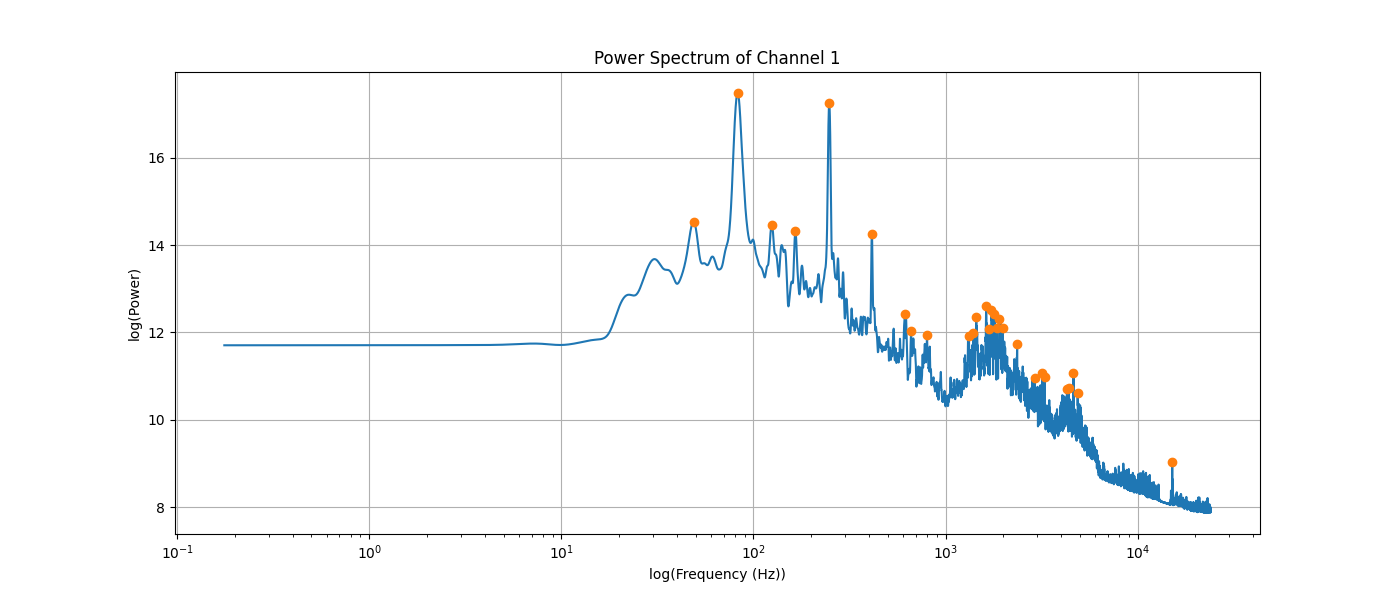

In [193]:
plt.figure(figsize=(14, 6))

freqs_channel1 = freqs_channel1[1:]  # Escludi la frequenza zero

plt.plot(freqs_channel1, log_spectrum, label='Log Power Spectrum')
plt.plot(freqs_channel1[peaks], log_spectrum[peaks], "o", label='Peaks (Fine)')

plt.xscale('log')

plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Power)')
plt.title('Power Spectrum of Channel 1')
plt.grid()
plt.show()

In [194]:
first_n_peaks = peaks[:10]

# fit lineare per trovare la frequenza fondamentale
peak_freqs = log_freqs[first_n_peaks]
inds = np.arange(len(peak_freqs))
slope, intercept = np.polyfit(inds, peak_freqs, 1)

print(f"Estimated fundamental frequency: {10**intercept:.2f} Hz")

Estimated fundamental frequency: 58.20 Hz


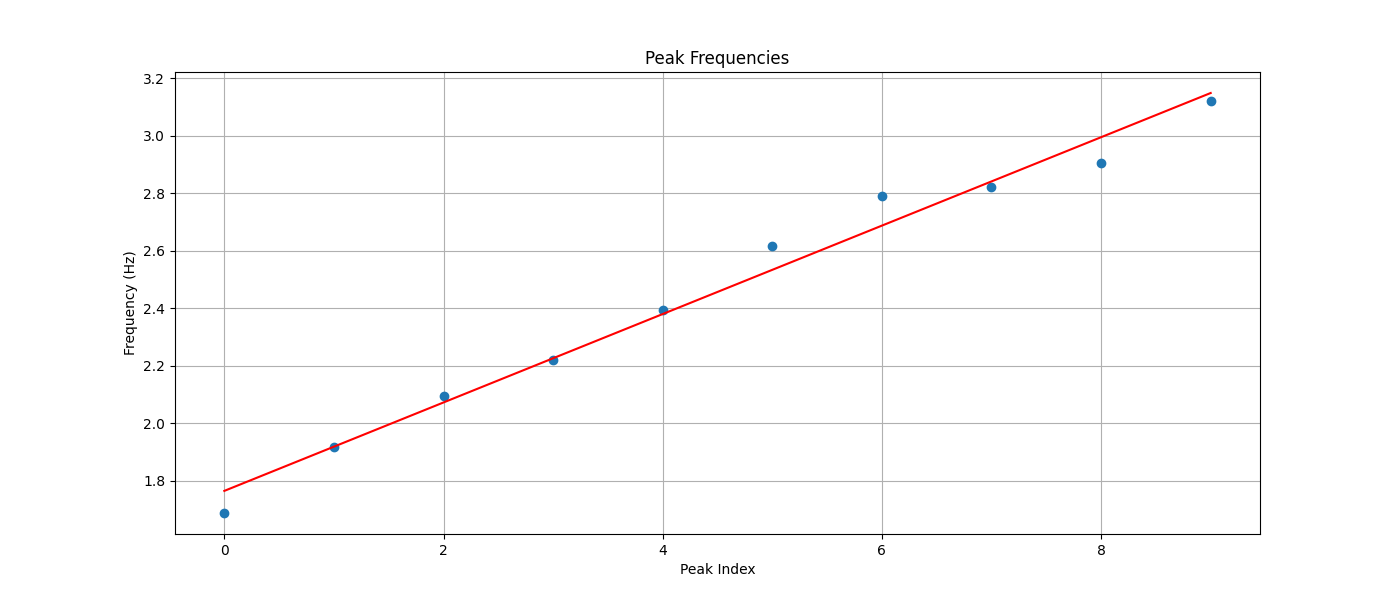

In [195]:
plt.figure(figsize=(14, 6))
plt.plot(inds, peak_freqs, "o")

plt.plot(inds, slope*inds + intercept, label='Linear Fit', color='red')

plt.xlabel('Peak Index')
plt.ylabel('Frequency (Hz)')
plt.title('Peak Frequencies')
plt.grid()
plt.show()

In [ ]:
def get_f0_from_gcd(freqs):
    fmin = np.min(freqs)
    fmax = np.max(freqs)
    candidates = np.arange(fmin/2, fmax, 0.1)

    best_f0 = None
    best_score = float('inf')

    for f0 in candidates:
        residual = np.sum(np.abs((freqs / f0) - np.round(freqs / f0)))
        if residual < best_score:
            best_score = residual
            best_f0 = f0
    
    return best_f0

estimated_f0 = get_f0_from_gcd(10**peak_freqs)
print(f"Estimated fundamental frequency (f0): {estimated_f0:.2f} Hz")

Best f0: 41.38 Hz with score: 0.7420
Estimated fundamental frequency (f0): 41.38 Hz
